In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr


In [113]:
# Name of shapefile/region
own_region = "manning"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_1991_2019_Forcing"

#Shape area
shape_area_manning = 6642 * 1000000 # m2

# Load evaporation data from ERA5 #m/day
evap_daily = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap_daily['Date'] = pd.to_datetime(evap_daily['system:index'], format='%Y%m%d')
evap_daily = evap_daily.set_index('Date')[['total_evaporation_sum']].rename(columns={'total_evaporation_sum': 'ERA5_Evaporation'})
# Take absolute value since evaporation is negative in ERA5 data
evap_daily['ERA5_Evaporation'] = evap_daily['ERA5_Evaporation'].abs()

#load precipitation data from ERA5 m/month
precip_daily = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip_daily['Date'] = pd.to_datetime(precip_daily['system:index'], format='%Y%m%d')
precip_daily = precip_daily.set_index('Date')[['total_precipitation_sum']].rename(columns={'total_precipitation_sum': 'ERA5_Precipitation'})      


In [114]:
# Period of interest
experiment_start_time = "1981-01-01T00:00:00Z"
experiment_end_time = "2025-12-31T00:00:00Z"

In [115]:
# fix units of evap and precip data
evap_daily['ERA5_Evaporation'] = evap_daily['ERA5_Evaporation'].abs() * 1000  # Convert m/day to mm/day (already basin-averaged)
precip_daily['ERA5_Precipitation'] = precip_daily['ERA5_Precipitation'] * 1000  # Convert m/day to mm/day (already basin-averaged)

#killawarra station id is 5202080
# Discharge data manning at killawarra station
Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=';',
    skiprows=36,
    header=0,
    encoding='cp1252',
    index_col=0,
    parse_dates=True
)
Obs.index.name = 'Day'
Obs = Obs.rename(columns={' Value': 'Q'})  # Note the space before Value
Obs['Q'] = Obs['Q'] * 86400 / shape_area_manning * 1000  # Convert m³/s to mm/day
Obs.loc[Obs['Q'] > 4000, 'Q'] = np.nan
Obs_1 = Obs.loc['1981-01-01':'2025-12-31']
Obs_data = Obs_1['Q'].to_xarray().rename({'Day': 'time'})

In [116]:
precip_xr = precip_daily['ERA5_Precipitation'].to_xarray().rename({'Date': 'time'}).rename('P mm/d')
evap_xr = evap_daily['ERA5_Evaporation'].to_xarray().rename({'Date': 'time'}).rename('EP mm/d')
obs_xr = Obs_data.rename('Q mm/d')

df = xr.merge([precip_xr, evap_xr, obs_xr]).to_dataframe()
data = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
data.index = pd.to_datetime(data.index)

c_pre_deforestation = data.loc["1991-01-01":"1994-12-31"]
c_post_deforestation = data.loc["1996-01-01":"1999-12-31"]
c_pre_deforestation

C:\Users\madis\AppData\Local\Temp\ipykernel_4396\1672104322.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  df = xr.merge([precip_xr, evap_xr, obs_xr]).to_dataframe()


,P mm/d,EP mm/d,Q mm/d
time,,,
1991-01-01,0.654111,3.679258,0.174439
1991-01-02,0.683483,3.612146,0.162667
1991-01-03,0.001344,3.930138,0.139135
1991-01-04,0.139281,3.451699,0.119597
1991-01-05,22.472925,3.242747,0.099265
...,...,...,...
1994-12-27,0.001297,4.439361,0.025912
1994-12-28,0.003711,4.470221,0.108267
1994-12-29,1.687586,3.544030,0.196046


In [117]:
#calculate et as p - q
c_pre_deforestation["ET mm/d"] = (
    c_pre_deforestation["P mm/d"] - c_pre_deforestation["Q mm/d"]
)

c_post_deforestation["ET mm/d"] = (
    c_post_deforestation["P mm/d"] - c_post_deforestation["Q mm/d"]
)

# Also calculate for the full data
data["ET mm/d"] = data["P mm/d"] - data["Q mm/d"]

#did the budyko change?
P_pre = c_pre_deforestation["P mm/d"].mean()
EP_pre = c_pre_deforestation["EP mm/d"].mean()
ET_pre = c_pre_deforestation["ET mm/d"].mean()

P_post = c_post_deforestation["P mm/d"].mean()
EP_post = c_post_deforestation["EP mm/d"].mean()
ET_post = c_post_deforestation["ET mm/d"].mean()


AI_pre = EP_pre / P_pre
EI_pre = ET_pre / P_pre

AI_post = EP_post / P_post
EI_post = ET_post / P_post


C:\Users\madis\AppData\Local\Temp\ipykernel_4396\4166066476.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_pre_deforestation["ET mm/d"] = (
C:\Users\madis\AppData\Local\Temp\ipykernel_4396\4166066476.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_post_deforestation["ET mm/d"] = (


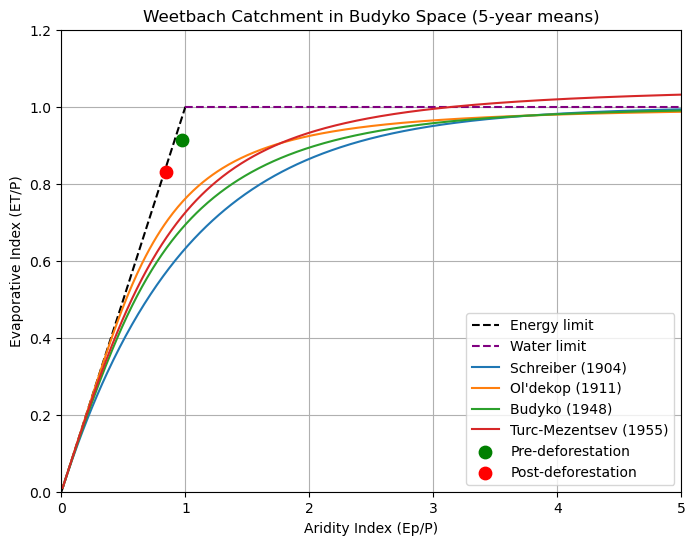

In [118]:
#plot in the budyko framework
plt.figure(figsize=(8,6))
plt.xlim(0, 5)
plt.ylim(0, 1.2)

phi = np.linspace(0.01, 5, 500)

EaP_schreiber = 1 - np.exp(-phi)
EaP_oldekop = phi * np.tanh(1 / phi)
EaP_budyko = np.sqrt(phi * np.tanh(1/phi) * (1 - np.exp(-phi)))
EaP_turc = 1 / np.sqrt(0.9 + (1/phi)**2)



# Energy limit (0–1)
phi_energy = np.linspace(0, 1, 200)
plt.plot(phi_energy, phi_energy, 'k--', label='Energy limit')

# Water limit (1–5)
phi_water = np.linspace(1, 5, 200)
plt.hlines(1, 1, 5, colors='purple', linestyles='--', label='Water limit')

# Analytical curves
plt.plot(phi, EaP_schreiber, label='Schreiber (1904)')
plt.plot(phi, EaP_oldekop, label="Ol'dekop (1911)")
plt.plot(phi, EaP_budyko, label='Budyko (1948)')
plt.plot(phi, EaP_turc, label='Turc-Mezentsev (1955)')

# Pre- and post-deforestation points
plt.scatter(AI_pre, EI_pre, color='green', s=80, label='Pre-deforestation', zorder=5)
plt.scatter(AI_post, EI_post, color='red', s=80, label='Post-deforestation', zorder=5)

plt.xlabel("Aridity Index (Ep/P)")
plt.ylabel("Evaporative Index (ET/P)")
plt.title("Weetbach Catchment in Budyko Space (5-year means)")
plt.legend()
plt.grid(True)
plt.show()


In [119]:
# Interception capacity
Si_max = 2.5  # mm
Si = 0        # initial storage

Pe_list = []
Ei_list = []
Si_list = []

for P, Ep in zip(data["P mm/d"], data["EP mm/d"]):
    
    # 1. Add precipitation
    Si += P
    
    # 2. Throughfall if storage exceeds capacity
    Pe = max(0, Si - Si_max)
    Si -= Pe
    
    # 3. Interception evaporation
    Ei = min(Ep, Si)
    Si -= Ei
    
    # Store results
    Pe_list.append(Pe)
    Ei_list.append(Ei)
    Si_list.append(Si)

# Add to dataframe
data["Pe mm/d"] = Pe_list
data["Ei mm/d"] = Ei_list
data["Si mm"] = Si_list

# Ensure subsets have the new column
c_pre_deforestation["Pe mm/d"] = data.loc[c_pre_deforestation.index, "Pe mm/d"]
c_post_deforestation["Pe mm/d"] = data.loc[c_post_deforestation.index, "Pe mm/d"]
c_pre_deforestation["Si mm"] = data.loc[c_pre_deforestation.index, "Si mm"]
c_post_deforestation["Si mm"] = data.loc[c_post_deforestation.index, "Si mm"]


C:\Users\madis\AppData\Local\Temp\ipykernel_4396\1888514692.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_pre_deforestation["Pe mm/d"] = data.loc[c_pre_deforestation.index, "Pe mm/d"]
C:\Users\madis\AppData\Local\Temp\ipykernel_4396\1888514692.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_post_deforestation["Pe mm/d"] = data.loc[c_post_deforestation.index, "Pe mm/d"]
C:\Users\madis\AppData\Local\Temp\ipykernel_4396\1888514692.py:35: SettingWithCopyWarning: 
A value is trying to be set on a

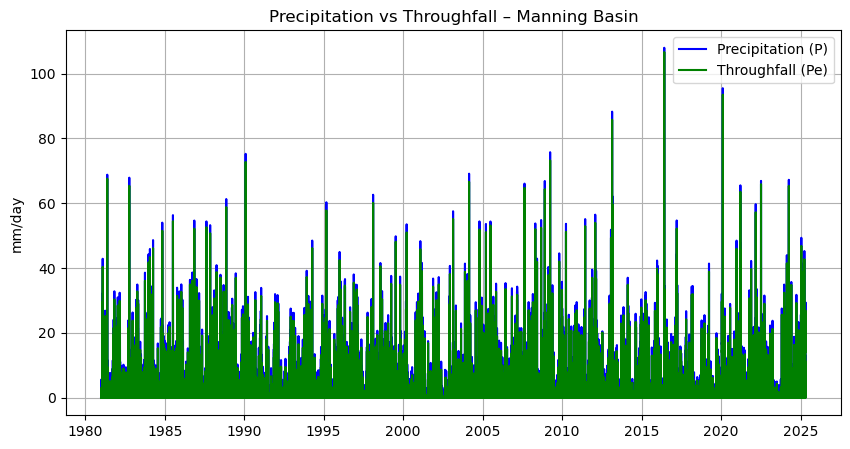

In [120]:
plt.figure(figsize=(10,5))

plt.plot(data.index, data["P mm/d"], label="Precipitation (P)", color="blue")
plt.plot(data.index, data["Pe mm/d"], label="Throughfall (Pe)", color="green")

plt.ylabel("mm/day")
plt.title("Precipitation vs Throughfall – Manning Basin")
plt.legend()
plt.grid(True)
plt.show()


In [121]:
ratio = data["Pe mm/d"].mean() / data["P mm/d"].mean()
ratio


ratio_pre = c_pre_deforestation["Pe mm/d"].mean() / c_pre_deforestation["P mm/d"].mean()
ratio_post = c_post_deforestation["Pe mm/d"].mean() / c_post_deforestation["P mm/d"].mean()


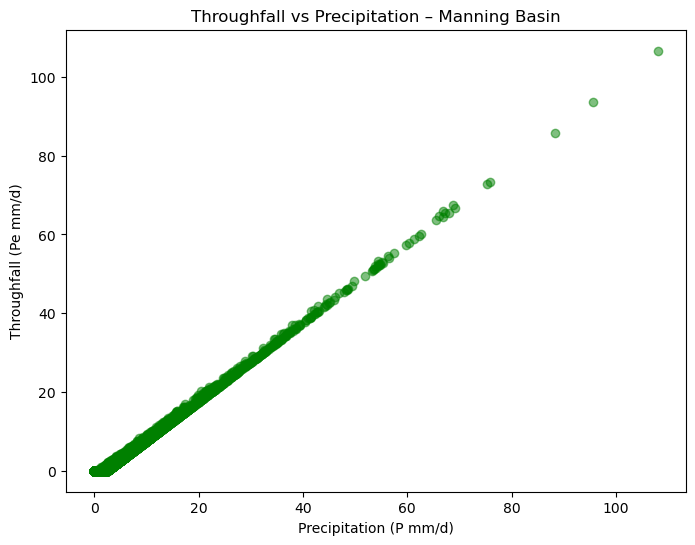

In [122]:
#look at this as a scatter plot of Pe vs P
plt.figure(figsize=(8,6))
plt.scatter(data["P mm/d"], data["Pe mm/d"], alpha=0.5, color='green')
plt.xlabel("Precipitation (P mm/d)")
plt.ylabel("Throughfall (Pe mm/d)")
plt.title("Throughfall vs Precipitation – Manning Basin")
plt.show()

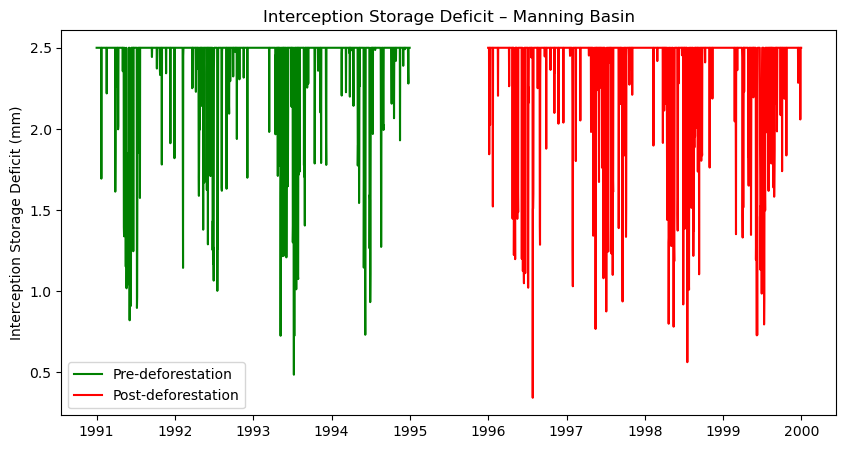

In [123]:
#plot storage deficit per year for pre and post deforestation
plt.figure(figsize=(10,5))
Si_max = 2.5  # mm
plt.plot(c_pre_deforestation.index, Si_max - c_pre_deforestation["Si mm"], label="Pre-deforestation", color="green")
plt.plot(c_post_deforestation.index, Si_max - c_post_deforestation["Si mm"], label="Post-deforestation", color="red")
plt.ylabel("Interception Storage Deficit (mm)")
plt.title("Interception Storage Deficit – Manning Basin")
plt.legend()
plt.show()

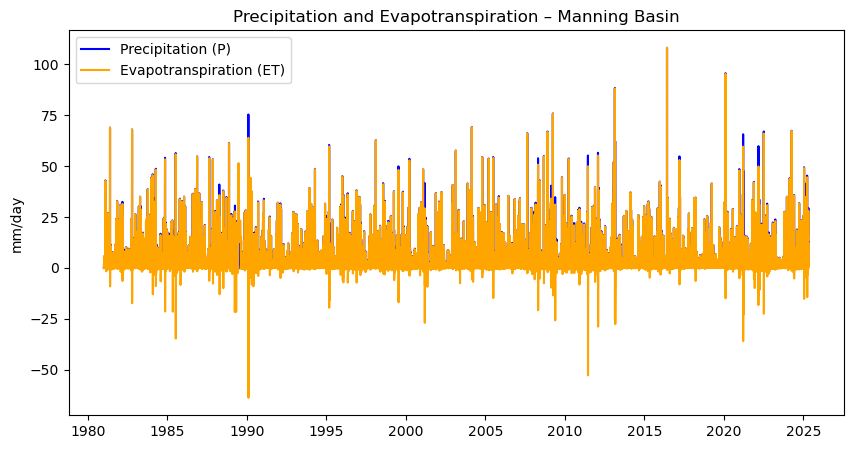

In [124]:
#plot daily precipitation and et as mm/day per year

plt.figure(figsize=(10,5))
plt.plot(data.index, data["P mm/d"], label="Precipitation (P)", color="blue")
plt.plot(data.index, data["ET mm/d"], label="Evapotranspiration (ET)", color="orange")
plt.ylabel("mm/day")
plt.title("Precipitation and Evapotranspiration – Manning Basin")
plt.legend()
plt.show()

**Everything below this is from exercises worked in the afternoon practicals.**

In [125]:
# si_max = 2.5  # mm
# Si1 = 0
# Si2 = 0

# catchment["Pe_ger"] = 0.0
# catchment["Pe_scot"] = 0.0

# for i in range(len(catchment)):
#     # Germany
#     P = catchment["precip1"].iloc[i]
#     Ep = catchment["ep1"].iloc[i]

#     Si_temp = Si1 + P

#     if Si_temp > si_max:
#         Pe = Si_temp - si_max
#         Si_temp = si_max
#     else:
#         Pe = 0

#     Ei = min(Ep, Si_temp)
#     Si1 = Si_temp - Ei

#     catchment.loc[catchment.index[i], "Pe_ger"] = Pe

#     # Scotland
#     P = catchment["precip2"].iloc[i]
#     Ep = catchment["ep2"].iloc[i]

#     Si_temp = Si2 + P

#     if Si_temp > si_max:
#         Pe = Si_temp - si_max
#         Si_temp = si_max
#     else:
#         Pe = 0

#     Ei = min(Ep, Si_temp)
#     Si2 = Si_temp - Ei

#     catchment.loc[catchment.index[i], "Pe_scot"] = Pe

In [126]:
# ratio_ger = catchment["Pe_ger"].mean() / catchment["precip1"].mean()
# ratio_scot = catchment["Pe_scot"].mean() / catchment["precip2"].mean()

# print(f"Germany Pe/P = {ratio_ger:.2f}")
# print(f"Scotland Pe/P = {ratio_scot:.2f}")

In [127]:
# catchment[["precip1", "Pe_ger"]].plot()
# plt.ylabel("mm/d")
# plt.title("Germany precipitation vs throughfall")
# plt.show()

In [128]:
# plt.scatter(catchment["precip1"], catchment["Pe_ger"], label="Germany")
# plt.scatter(catchment["precip2"], catchment["Pe_scot"], label="Scotland")

# plt.xlabel("Precipitation (mm/d)")
# plt.ylabel("Throughfall Pe (mm/d)")
# plt.legend()
# plt.show()

In [129]:

# file2 = "Rootzone Storage Capacity.xlsx"
# rootzone = pd.read_excel(file2, index_col= 0, parse_dates= True, skiprows = 2)
# rootzone = rootzone.dropna()

# rootzone.columns = ["P_pre", "EP_pre", "Q_pre", "Date_post", "P_post", "EP_post", "Q_post"]

# rootzone.head()


In [130]:
# # pre-deforestation
# pre = rootzone[["P_pre", "EP_pre", "Q_pre"]].copy()

# # post-deforestation
# post = rootzone[["Date_post", "P_post", "EP_post", "Q_post"]].copy()
# post = post.dropna()
# post["Date_post"] = pd.to_datetime(post["Date_post"])
# post = post.set_index("Date_post")
# print(pre.head())
# print(post.head())


In [131]:
# pre["ET"] = pre["P_pre"] - pre["Q_pre"]
# post["ET"] = post["P_post"] - post["Q_post"]
# pre["ET"] = pre["ET"].clip(lower=0)
# post["ET"] = post["ET"].clip(lower=0)

In [132]:

# # 1) Long-term mean ET from the water balance
# ET_mean_pre = pre["P_pre"].mean() - pre["Q_pre"].mean()
# ET_mean_post = post["P_post"].mean() - post["Q_post"].mean()

# # 2) Scale daily ET with daily EP
# pre["ET_daily"] = (pre["EP_pre"] / pre["EP_pre"].mean()) * ET_mean_pre
# post["ET_daily"] = (post["EP_post"] / post["EP_post"].mean()) * ET_mean_post

# # 3) Compute storage deficit for pre-deforestation period
# sd_pre = [0.0]

# for i in range(1, len(pre)):
#     new_sd = min(0, sd_pre[i-1] + pre["P_pre"].iloc[i] - pre["ET_daily"].iloc[i])
#     sd_pre.append(new_sd)

# pre["SD"] = sd_pre

# # 4) Compute storage deficit for post-deforestation period
# sd_post = [0.0]

# for i in range(1, len(post)):
#     new_sd = min(0, sd_post[i-1] + post["P_post"].iloc[i] - post["ET_daily"].iloc[i])
#     sd_post.append(new_sd)

# post["SD"] = sd_post

# # 5) Root-zone storage capacity = maximum storage deficit
# SR_pre = (-pre["SD"]).max()
# SR_post = (-post["SD"]).max()

# print("SR pre-deforestation =", SR_pre, "mm")
# print("SR post-deforestation =", SR_post, "mm")

In [133]:
# plt.figure(figsize=(10,4))
# plt.plot(pre["SD"], label="Pre-deforestation")
# plt.plot(post["SD"], label="Post-deforestation")

# plt.axhline(0)
# plt.ylabel("Storage deficit (mm)")
# plt.title("Storage deficit through time")
# plt.legend()


# x_pre = pre["EP_pre"].mean() / pre["P_pre"].mean()
# y_pre = ET_mean_pre / pre["P_pre"].mean()

# x_post = post["EP_post"].mean() / post["P_post"].mean()
# y_post = ET_mean_post / post["P_post"].mean()

# plt.figure(figsize=(6,6))
# plt.scatter(x_pre, y_pre, label="Pre-deforestation")
# plt.scatter(x_post, y_post, label="Post-deforestation")

# plt.xlabel("EP / P")
# plt.ylabel("ET / P")
# plt.title("Budyko space")
# plt.legend()


# plt.figure(figsize=(10,4))
# plt.plot(pre["P_pre"], label="Precipitation")
# plt.plot(pre["ET_daily"], label="ET")

# plt.ylabel("mm/day")
# plt.title("Daily precipitation vs ET")
# plt.legend()